In [1]:
# Color space visualization
# Converter uses skimage.color (rgb2hsv, rgb2lab) 
import sys
sys.path.append('../src')

from torchvision import datasets
import numpy as np
import matplotlib.pyplot as plt

from color_dg.color_spaces.converter import ColorspaceConverter

/home/stud/gnjinkap/miniforge3/envs/thesis/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
from torchvision import datasets
import numpy as np

# Load the  dataset CIFAR-10
dataset = datasets.CIFAR10(root='../data', train=True, download=True)

# Take the first image
image_pil, label = dataset[0] # image_pil: the first image in the dataset, label: the corresponding label (class index) for that image

# Convert to a NumPy array
image_rgb = np.array(image_pil)

print("Shape :", image_rgb.shape) # (32, 32, 3): image of 32x32 pixels with 3 color channels (RGB)
print("Type  :", image_rgb.dtype) # uint8: unsigned integer (0 to 255) for each color channel (Red, Green, Blue)
print("Classe:", dataset.classes[label])# frog: the label corresponds to the class "frog" in the CIFAR-10 dataset


/home/stud/gnjinkap/miniforge3/envs/thesis/lib/python3.11/site-packages/torchvision/datasets/cifar.py:83: VisibleDeprecationWarning: dtype(): align should be passed as Python or NumPy boolean but got `align=0`. Did you mean to pass a tuple to create a subarray type? (Deprecated NumPy 2.4)
  entry = pickle.load(f, encoding="latin1")


Shape : (32, 32, 3)
Type  : uint8
Classe: frog


In [3]:
# Apply the 4 conversions
# skimage.color.rgb2hsv  → H, S, V all in [0, 1]
# skimage.color.rgb2lab  → L:[0,100]→/100→[0,1] | a,b:[-128,127]→(+128)/255→[0,1]
# cv2.COLOR_RGB2GRAY     → [0,1] duplicated 3× for ResNet compatibility
image_hsv  = ColorspaceConverter.rgb_to_hsv(image_rgb)
image_lab  = ColorspaceConverter.rgb_to_lab(image_rgb)
image_gray = ColorspaceConverter.rgb_to_grayscale(image_rgb)
image_rgb_norm = image_rgb.astype(np.float32) / 255.0

print(f"RGB  | min={image_rgb_norm.min():.3f}  max={image_rgb_norm.max():.3f}")
print(f"HSV  | min={image_hsv.min():.3f}  max={image_hsv.max():.3f}  "
      f"→ H:{image_hsv[:,:,0].max():.3f}  S:{image_hsv[:,:,1].max():.3f}  V:{image_hsv[:,:,2].max():.3f}")
print(f"LAB  | min={image_lab.min():.3f}  max={image_lab.max():.3f}  "
      f"→ L:{image_lab[:,:,0].max():.3f}  a:{image_lab[:,:,1].max():.3f}  b:{image_lab[:,:,2].max():.3f}")
print(f"GRAY | min={image_gray.min():.3f}  max={image_gray.max():.3f}")

RGB  | min=0.000  max=1.000
HSV  | min=0.000  max=1.000  → H:0.963  S:1.000  V:1.000
LAB  | min=0.000  max=0.990  → L:0.990  a:0.655  b:0.764
GRAY | min=0.000  max=0.984


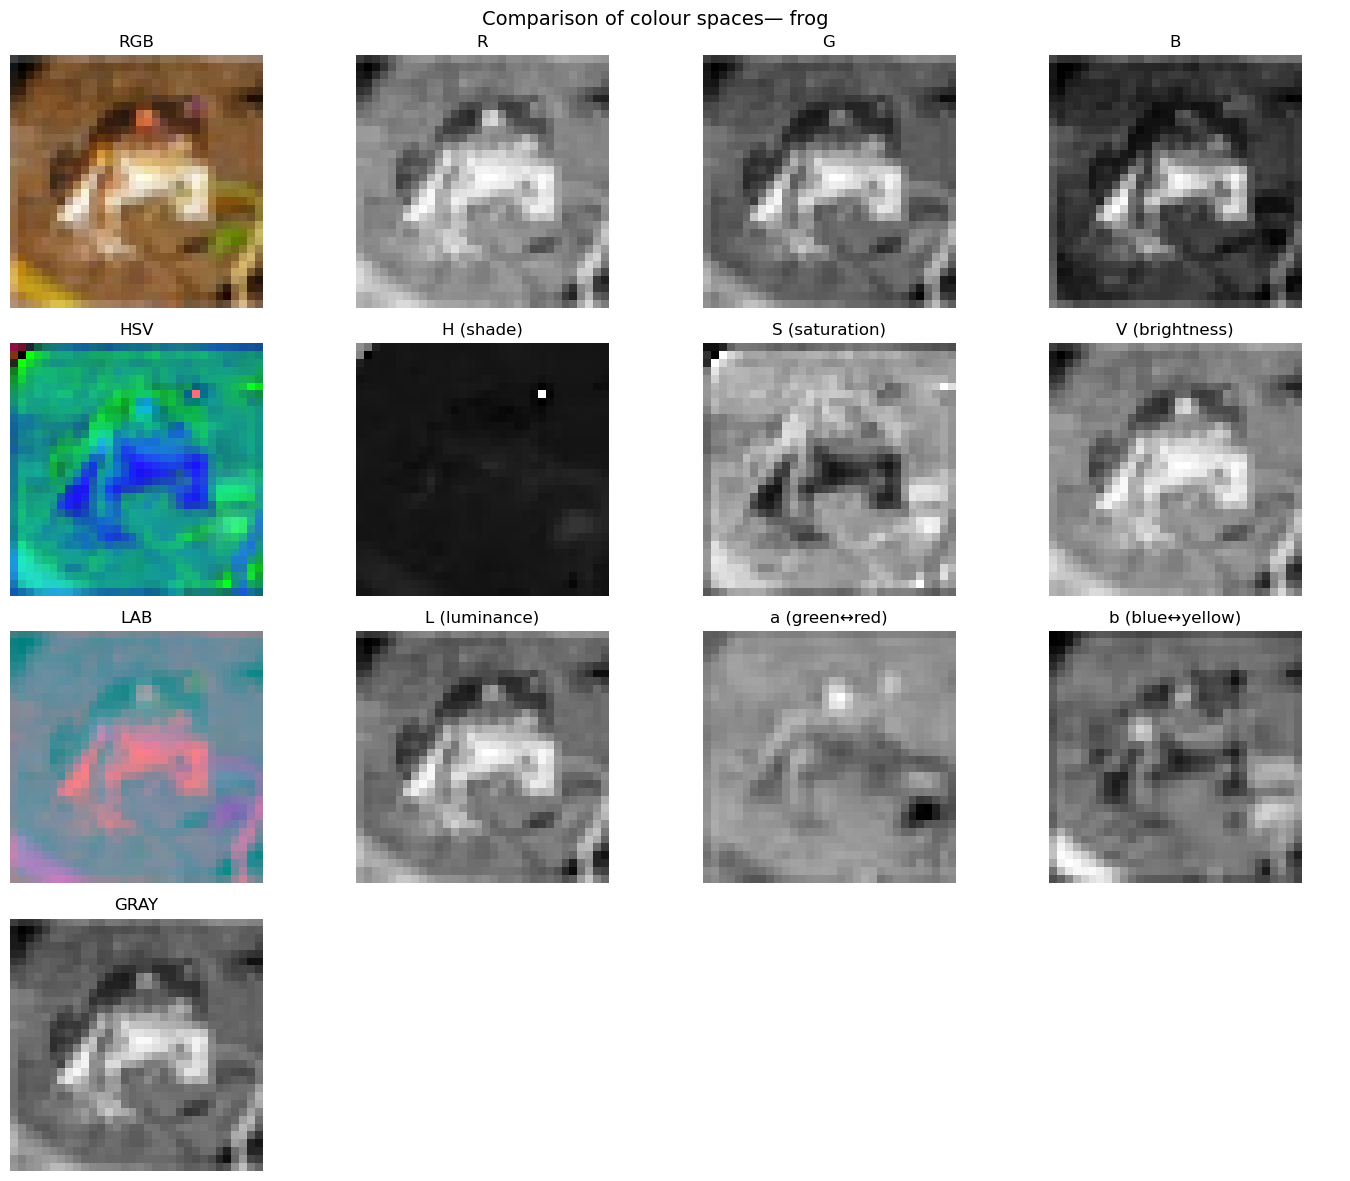

In [4]:
fig, axes = plt.subplots(4, 4, figsize=(14, 12))
fig.suptitle("Comparison of colour spaces— " + dataset.classes[label], fontsize=14)

name_rgb  = ["R", "G", "B"]
name_hsv  = ["H (shade)", "S (saturation)", "V (brightness)"]
name_lab  = ["L (luminance)", "a (green↔red)", "b (blue↔yellow)"]

lines = [
    (image_rgb_norm, "RGB",  name_rgb),
    (image_hsv,      "HSV",  name_hsv),
    (image_lab,      "LAB",  name_lab),
]

for i, (image, name, name_canaux) in enumerate(lines):
    # Full image
    axes[i, 0].imshow(image)
    axes[i, 0].set_title(name)
    axes[i, 0].axis('off')

    # The 3 channels separately
    for j in range(3):
        axes[i, j+1].imshow(image[:, :, j], cmap='gray')
        axes[i, j+1].set_title(name_canaux[j])
        axes[i, j+1].axis('off')

# Line 4 : Grayscale (one single image)
axes[3, 0].imshow(image_gray)
axes[3, 0].set_title("GRAY")
axes[3, 0].axis('off')
for j in range(1, 4):
    axes[3, j].axis('off')

plt.tight_layout()
plt.show()


## Channel Correlation Analysis

RGB channels are highly correlated (R, G, B tend to move together).  
LAB separates luminance (L) from chrominance (a, b) — the channels are more independent.  
The histograms below show this difference on the CIFAR-10 image sample.

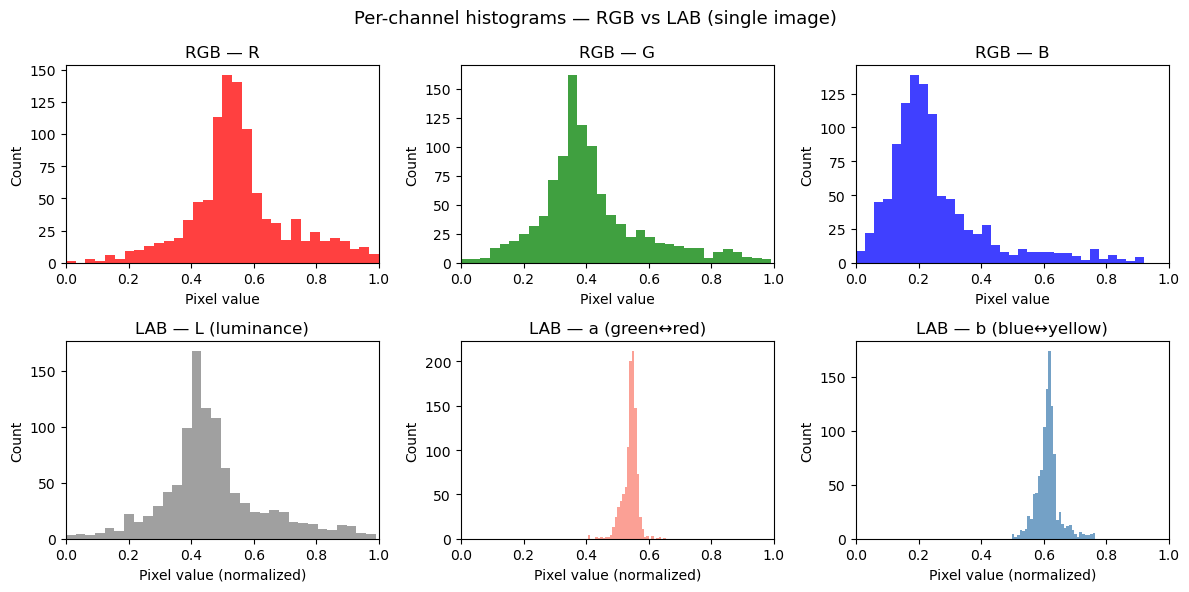

In [5]:
fig, axes = plt.subplots(2, 3, figsize=(12, 6))
fig.suptitle("Per-channel histograms — RGB vs LAB (single image)", fontsize=13)

rgb_names  = ["R", "G", "B"]
rgb_colors = ["red", "green", "blue"]
for j in range(3):
    axes[0, j].hist(image_rgb_norm[:, :, j].ravel(), bins=32, color=rgb_colors[j], alpha=0.75)
    axes[0, j].set_title(f"RGB — {rgb_names[j]}")
    axes[0, j].set_xlim(0, 1)
    axes[0, j].set_xlabel("Pixel value")
    axes[0, j].set_ylabel("Count")

lab_names  = ["L (luminance)", "a (green↔red)", "b (blue↔yellow)"]
lab_colors = ["gray", "salmon", "steelblue"]
for j in range(3):
    axes[1, j].hist(image_lab[:, :, j].ravel(), bins=32, color=lab_colors[j], alpha=0.75)
    axes[1, j].set_title(f"LAB — {lab_names[j]}")
    axes[1, j].set_xlim(0, 1)
    axes[1, j].set_xlabel("Pixel value (normalized)")
    axes[1, j].set_ylabel("Count")

plt.tight_layout()
plt.show()

### Inter-channel Correlation — 1000 CIFAR-10 images

A single image is not statistically representative. We compute the inter-channel correlation
matrix over **1000 images × 1024 pixels = 1 024 000 pixel samples** per colorspace.

A value close to **1.0** means two channels are redundant (correlated).  
A value close to **0.0** means two channels carry independent information (decorrelated).

In [6]:
N = 1000
converter = ColorspaceConverter()

rgb_pixels, hsv_pixels, lab_pixels = [], [], []

for i in range(N):
    img_pil, _ = dataset[i]
    img_np = np.array(img_pil)  # (32, 32, 3) uint8

    rgb_pixels.append((img_np.astype(np.float32) / 255.0).reshape(-1, 3))
    hsv_pixels.append(converter.rgb_to_hsv(img_np).reshape(-1, 3))
    lab_pixels.append(converter.rgb_to_lab(img_np).reshape(-1, 3))

rgb_flat = np.vstack(rgb_pixels)  # (1 024 000, 3)
hsv_flat = np.vstack(hsv_pixels)
lab_flat = np.vstack(lab_pixels)

corr_rgb = np.corrcoef(rgb_flat.T)
corr_hsv = np.corrcoef(hsv_flat.T)
corr_lab = np.corrcoef(lab_flat.T)

print(f"Computed on {N} images × {32*32} pixels = {N*32*32:,} samples per colorspace\n")

labels_rgb = ["R", "G", "B"]
labels_hsv = ["H", "S", "V"]
labels_lab = ["L", "a", "b"]

for name, corr, ch_labels in [("RGB", corr_rgb, labels_rgb),
                                ("HSV", corr_hsv, labels_hsv),
                                ("LAB", corr_lab, labels_lab)]:
    print(f"{name} inter-channel correlation:")
    header = "       " + "  ".join(f"{l:>6}" for l in ch_labels)
    print(header)
    for i, row_label in enumerate(ch_labels):
        row = "  ".join(f"{corr[i,j]:6.3f}" for j in range(3))
        print(f"  {row_label}  [ {row} ]")
    print()

Computed on 1000 images × 1024 pixels = 1,024,000 samples per colorspace

RGB inter-channel correlation:
            R       G       B
  R  [  1.000   0.901   0.785 ]
  G  [  0.901   1.000   0.909 ]
  B  [  0.785   0.909   1.000 ]

HSV inter-channel correlation:
            H       S       V
  H  [  1.000  -0.089   0.020 ]
  S  [ -0.089   1.000  -0.267 ]
  V  [  0.020  -0.267   1.000 ]

LAB inter-channel correlation:
            L       a       b
  L  [  1.000  -0.112  -0.005 ]
  a  [ -0.112   1.000  -0.028 ]
  b  [ -0.005  -0.028   1.000 ]



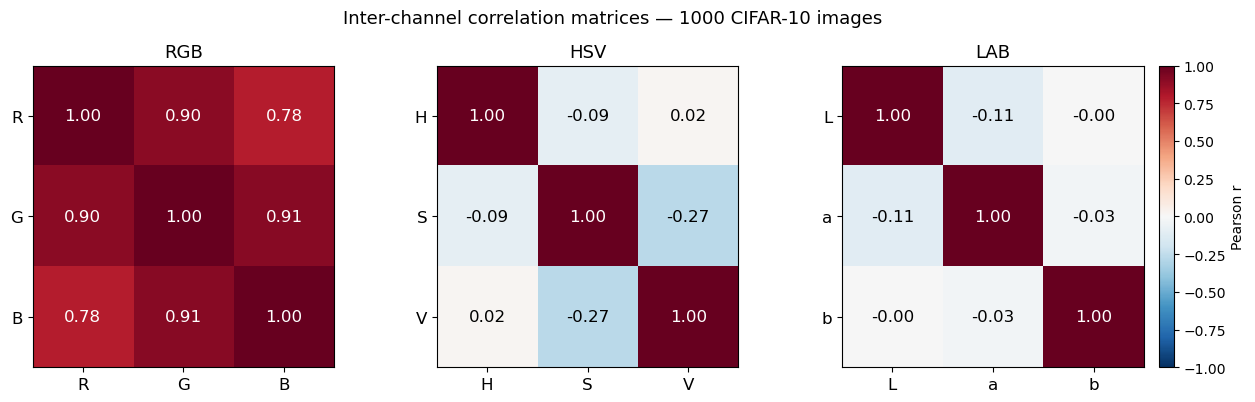

RGB  mean |off-diagonal correlation| = 0.865
HSV  mean |off-diagonal correlation| = 0.125
LAB  mean |off-diagonal correlation| = 0.048


In [7]:
fig, axes = plt.subplots(1, 3, figsize=(13, 4))
fig.suptitle("Inter-channel correlation matrices — 1000 CIFAR-10 images", fontsize=13)

configs = [
    ("RGB", corr_rgb, ["R", "G", "B"]),
    ("HSV", corr_hsv, ["H", "S", "V"]),
    ("LAB", corr_lab, ["L", "a", "b"]),
]

for ax, (name, corr, ch_labels) in zip(axes, configs):
    im = ax.imshow(corr, vmin=-1, vmax=1, cmap="RdBu_r")
    ax.set_xticks(range(3)); ax.set_xticklabels(ch_labels, fontsize=12)
    ax.set_yticks(range(3)); ax.set_yticklabels(ch_labels, fontsize=12)
    ax.set_title(name, fontsize=13)
    for i in range(3):
        for j in range(3):
            ax.text(j, i, f"{corr[i, j]:.2f}", ha="center", va="center",
                    fontsize=12, color="black" if abs(corr[i, j]) < 0.7 else "white")

fig.colorbar(im, ax=axes[-1], fraction=0.046, pad=0.04, label="Pearson r")
plt.tight_layout()
plt.show()

# Summary: mean absolute off-diagonal correlation per colorspace
for name, corr in [("RGB", corr_rgb), ("HSV", corr_hsv), ("LAB", corr_lab)]:
    off_diag = corr[~np.eye(3, dtype=bool)]
    print(f"{name}  mean |off-diagonal correlation| = {np.abs(off_diag).mean():.3f}")

## Training Results — ResNet-18 on CIFAR-10 (`results_v3/`)

Comparison of validation accuracy across all 4 colorspaces — **seed=42, 50 epochs**, StepLR drop at epoch 25.

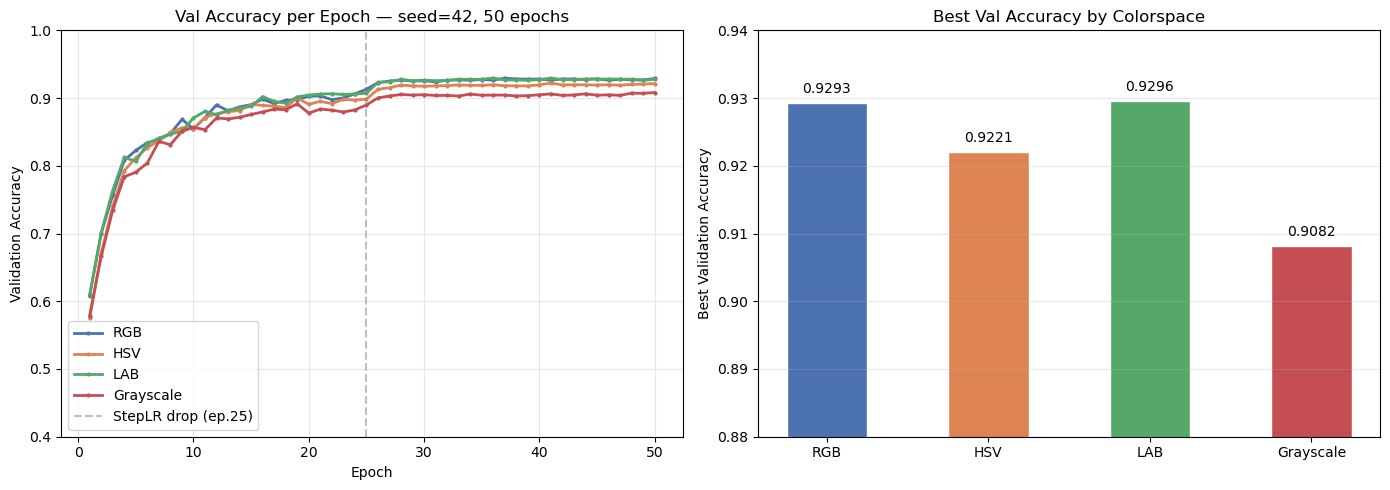


Ranking (seed=42, 50 epochs):
  1. LAB          0.9296
  2. RGB          0.9293
  3. HSV          0.9221
  4. Grayscale    0.9082


In [8]:
import csv, json, os

RESULTS_DIR = "../results_v3"
EXPERIMENTS = {
    "baseline_rgb":  "RGB",
    "exp_hsv":       "HSV",
    "exp_lab":       "LAB",
    "exp_grayscale": "Grayscale",
}
COLORS = ["#4C72B0", "#DD8452", "#55A868", "#C44E52"]

all_val_accs = {}
best_accs    = {}

for exp_name, label in EXPERIMENTS.items():
    path = os.path.join(RESULTS_DIR, exp_name)
    csv_path  = os.path.join(path, "metrics.csv")
    json_path = os.path.join(path, "summary.json")
    if not os.path.exists(csv_path):
        print(f"Missing: {csv_path}")
        continue
    val_accs = []
    with open(csv_path) as f:
        for row in csv.DictReader(f):
            val_accs.append(float(row["val_acc"]))
    with open(json_path) as f:
        summary = json.load(f)
    all_val_accs[label] = val_accs
    best_accs[label]    = summary["best_val_acc"]

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

for (label, val_accs), color in zip(all_val_accs.items(), COLORS):
    epochs = list(range(1, len(val_accs) + 1))
    ax1.plot(epochs, val_accs, label=label, color=color, linewidth=2, marker="o", markersize=2)

ax1.axvline(x=25, color="gray", linestyle="--", alpha=0.5, label="StepLR drop (ep.25)")
ax1.set_xlabel("Epoch")
ax1.set_ylabel("Validation Accuracy")
ax1.set_title("Val Accuracy per Epoch — seed=42, 50 epochs")
ax1.legend()
ax1.grid(True, alpha=0.3)
ax1.set_ylim(0.4, 1.0)

labels = list(best_accs.keys())
accs   = list(best_accs.values())
bars   = ax2.bar(labels, accs, color=COLORS[:len(labels)], width=0.5, edgecolor="white")
for bar, acc in zip(bars, accs):
    ax2.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.001,
             f"{acc:.4f}", ha="center", va="bottom", fontsize=10)
ax2.set_ylabel("Best Validation Accuracy")
ax2.set_title("Best Val Accuracy by Colorspace")
ax2.set_ylim(0.88, 0.94)
ax2.grid(axis="y", alpha=0.3)

plt.tight_layout()
plt.show()

print("\nRanking (seed=42, 50 epochs):")
for rank, (label, acc) in enumerate(sorted(best_accs.items(), key=lambda x: -x[1]), 1):
    print(f"  {rank}. {label:<12} {acc:.4f}")